# Column Descriptions

**Numerical Columns**

1. **id** – Unique id for each patient  
2. **age** – Age of the patient in years  
3. **trestbps** – Resting blood pressure in mm Hg  
4. **chol** – Serum cholesterol in mg/dl  
5. **thalach** – Maximum heart rate achieved  
6. **oldpeak** – ST depression induced by exercise relative to rest  
7. **ca** – Number of major vessels (0–3) colored by fluoroscopy  

**Ordinal Columns**

8. **cp** – Chest pain type: typical angina < atypical angina < non-anginal < asymptomatic  
9. **slope** – Slope of the peak exercise ST segment: upsloping < flat < downsloping  
10. **thal** – Heart defect: normal < fixed defect < reversible defect  

**Nominal Columns**

11. **origin** – Place of study  
12. **sex** – Male/Female  
13. **fbs** – Fasting blood sugar > 120 mg/dl  
14. **restecg** – Resting electrocardiographic results: normal, stt abnormality, lv hypertrophy  
15. **exang** – Exercise-induced angina: True/False  

**Target**

16. **num** – Predicted attribute (0–4) depending on severity

# Initialization

## Libraries

In [1]:
%pip install phik
%pip install gdown

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pprint import pprint
import os
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV

import numpy as np
import pandas as pd
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import phik

from ml.preprocessing import *
from ml.constants import *
from ml.data_prep import *
from ml.data_info import *
from ml.evaluation import *
from ml.data_visualization import *
from ml.utils import *

# Data Preperation

## Data Loading

In [3]:
dataset = load_drive_csv_data(GOOGLE_DRIVE_FILE_URL, CSV_PATH_STR)
dataset = binarize_target(dataset, target_col=TARGET_COL)
dataset = drop_irrelevant_features(dataset, cols_to_drop=IRRELEVANT_COLS)

dataset.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## Data Splitting

### Train/Test Split

In [4]:
train, test = stratified_train_test_split(
    df=dataset,
    test_size=TEST_PERCENT,
    random_state=SEED,
    stratify_cols=STRATIFIED_COLS
)

### Feature/Target Split

In [5]:
train_x, train_y = feature_target_split(train, TARGET_COL)
test_x, test_y = feature_target_split(test, TARGET_COL)

### Numerical/Categorical Split

In [6]:
print(f"Num cols: {NUM_COLS}")
print(f"Cat cols: {CAT_COLS}")

train_num = train[NUM_COLS]
train_cat = train[CAT_COLS]

Num cols: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
Cat cols: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'num']


# Data Exploration

## Overview

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 736 entries, 749 to 563
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       736 non-null    int64  
 1   sex       736 non-null    object 
 2   cp        736 non-null    object 
 3   trestbps  686 non-null    float64
 4   chol      713 non-null    float64
 5   fbs       663 non-null    object 
 6   restecg   734 non-null    object 
 7   thalch    689 non-null    float64
 8   exang     689 non-null    object 
 9   oldpeak   684 non-null    float64
 10  slope     484 non-null    object 
 11  ca        245 non-null    float64
 12  thal      345 non-null    object 
 13  num       736 non-null    int64  
dtypes: float64(5), int64(2), object(7)
memory usage: 86.2+ KB


In [8]:
train_num.describe()

,age,trestbps,chol,thalch,oldpeak
count,736.000000,686.00000,713.000000,689.000000,684.000000
mean,53.586957,132.21137,199.868163,137.831640,0.867251
std,9.387097,19.33864,110.908060,26.157964,1.081677
min,28.000000,0.00000,0.000000,60.000000,-2.600000
25%,47.000000,120.00000,175.000000,120.000000,0.000000
50%,54.000000,130.00000,224.000000,140.000000,0.500000
75%,60.000000,140.00000,269.000000,158.000000,1.500000
max,77.000000,200.00000,603.000000,202.000000,6.200000


In [9]:
train_num.skew()

age        -0.178959
trestbps    0.118099
chol       -0.618356
thalch     -0.229290
oldpeak     1.038296
dtype: float64

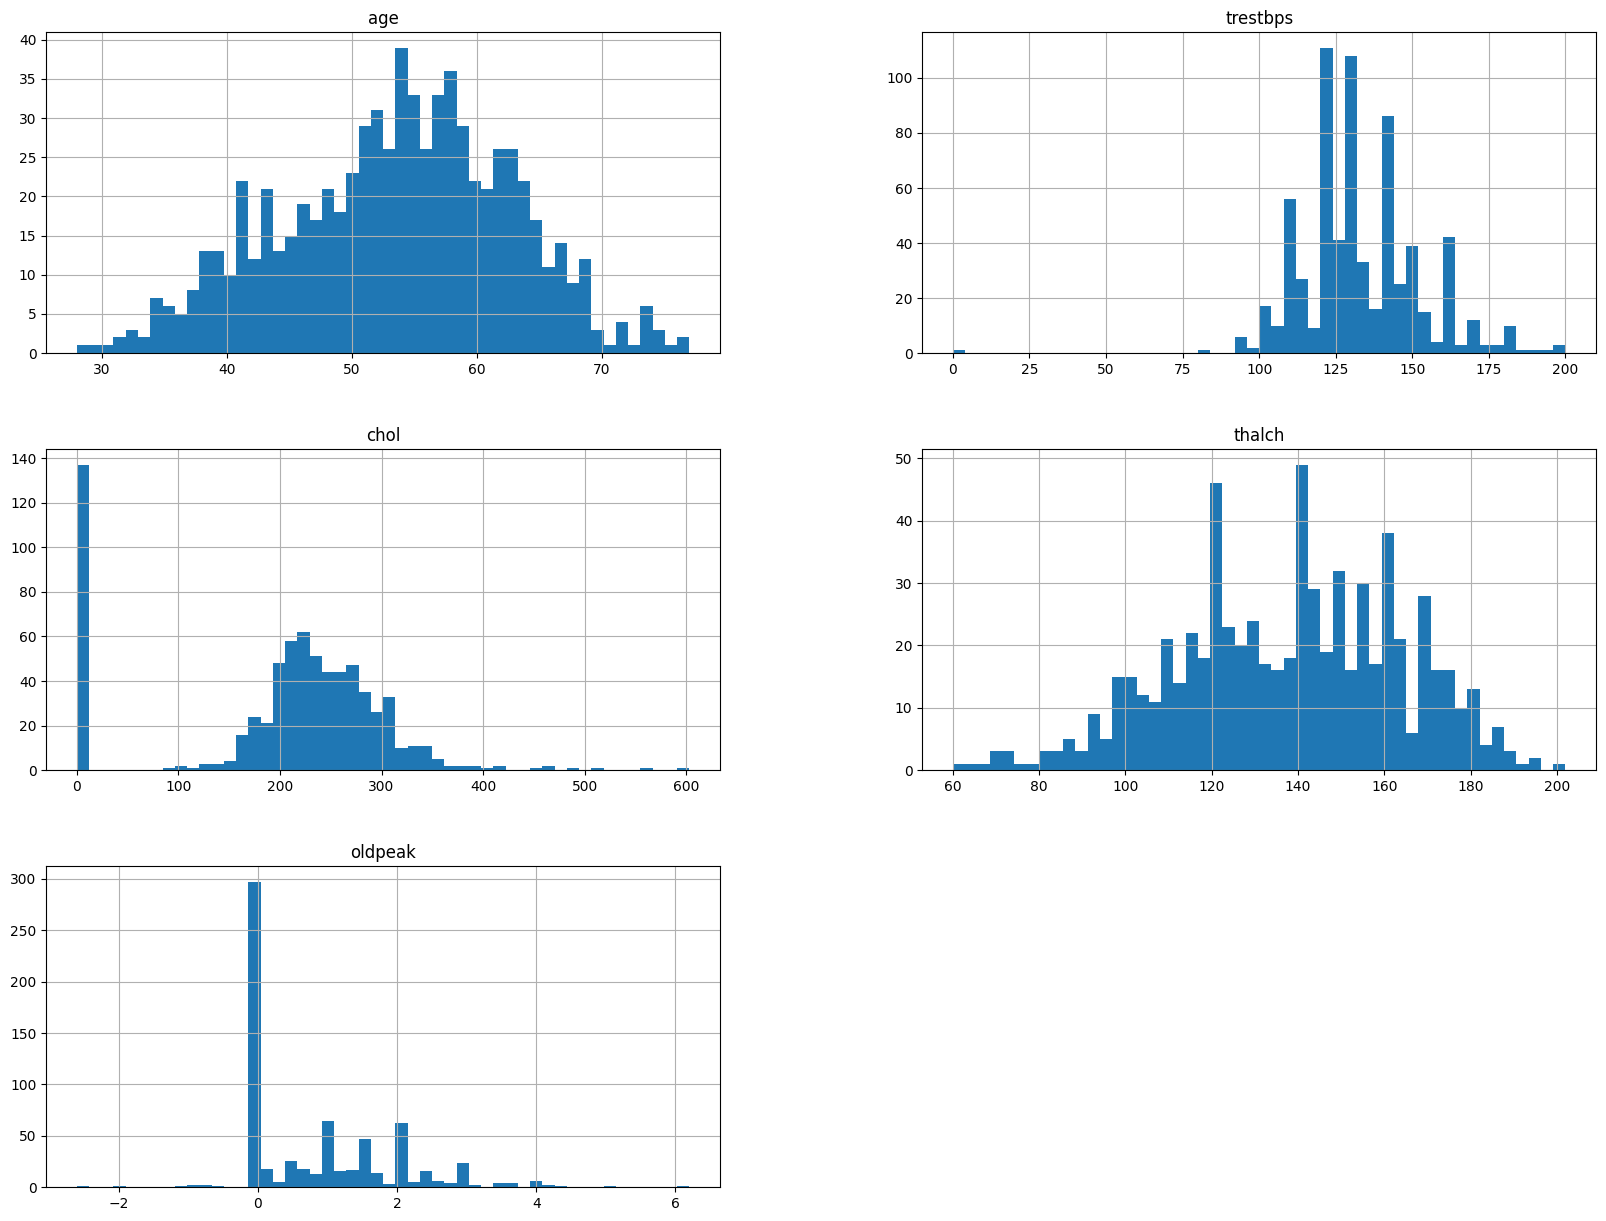

In [10]:
train_num.hist(bins=50, figsize=(20,15))
plt.show()


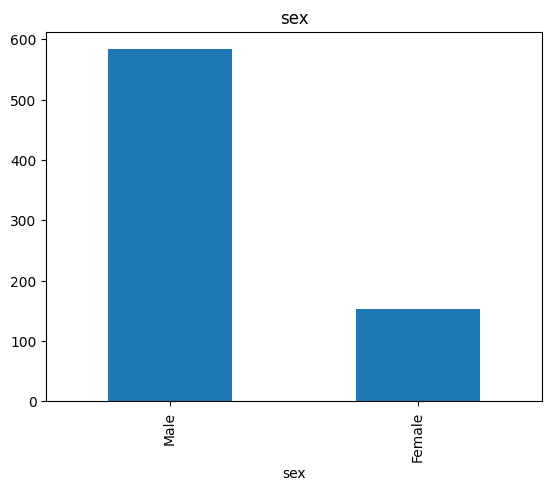

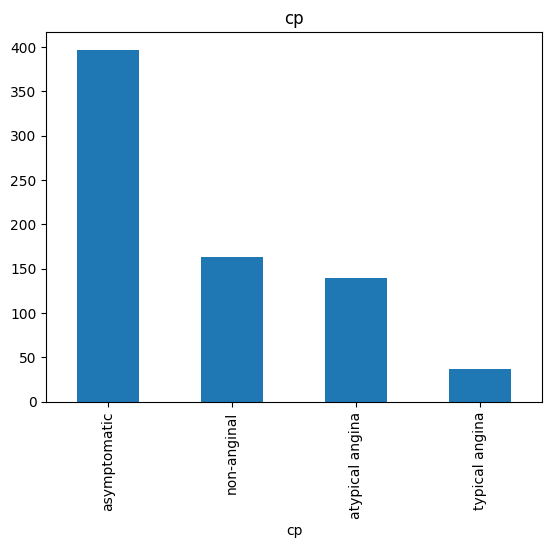

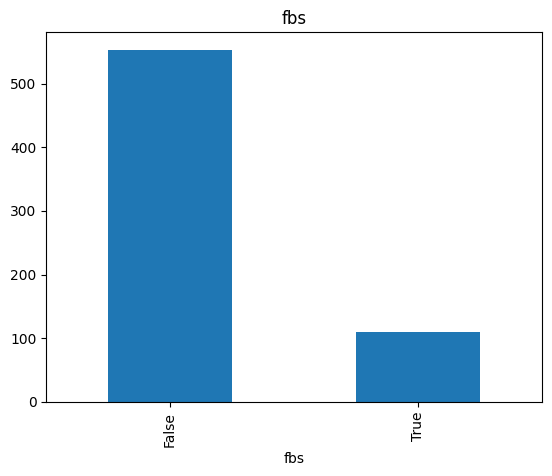

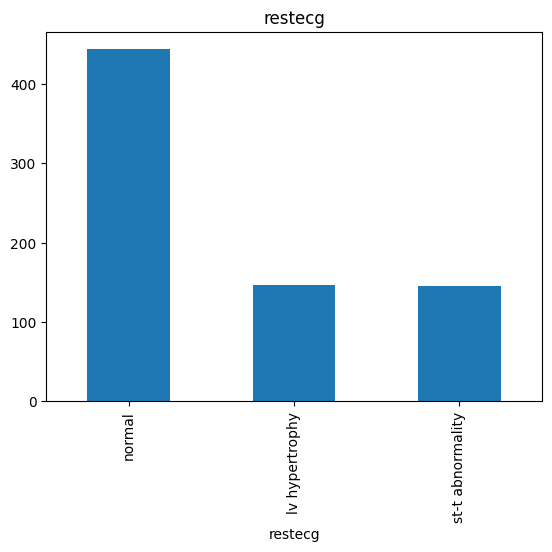

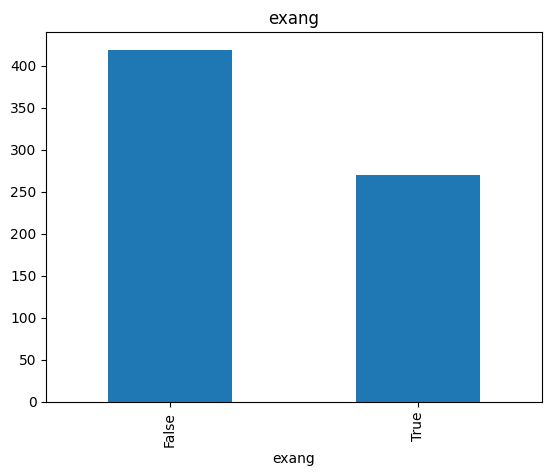

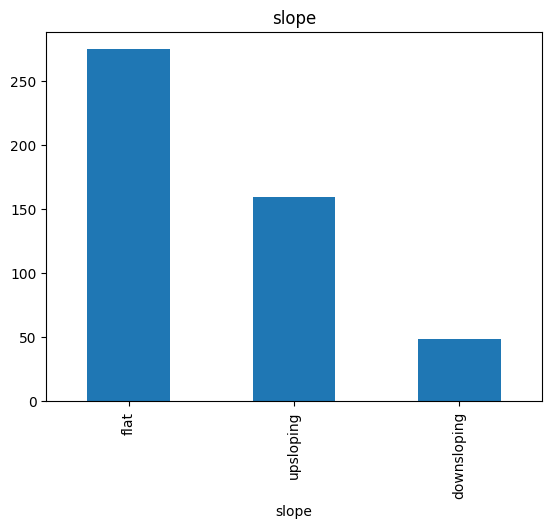

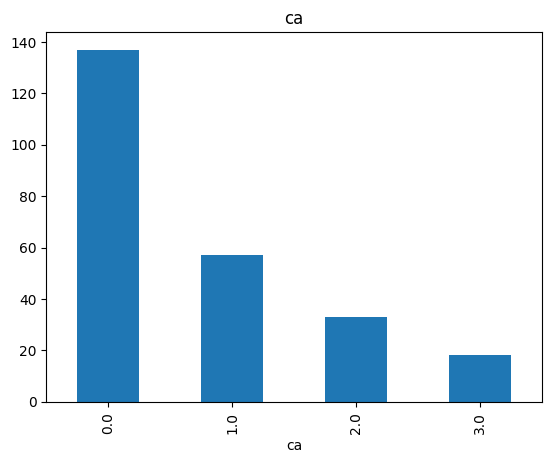

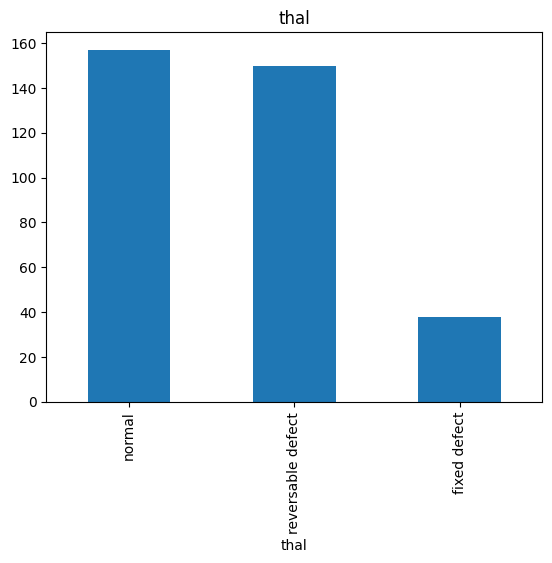

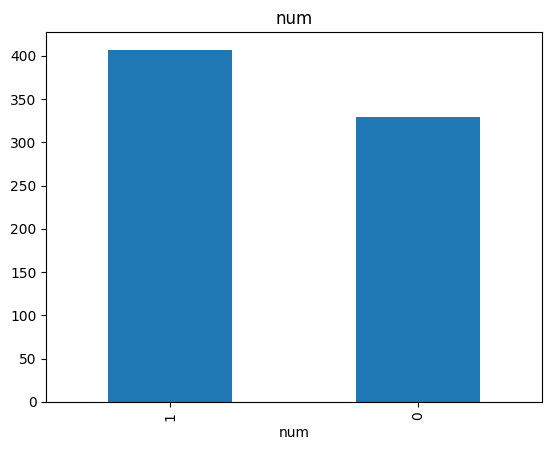

In [11]:
for col in CAT_COLS:
    train_cat[col].value_counts().plot(kind="bar")
    plt.title(col)
    plt.show()

## Correlation

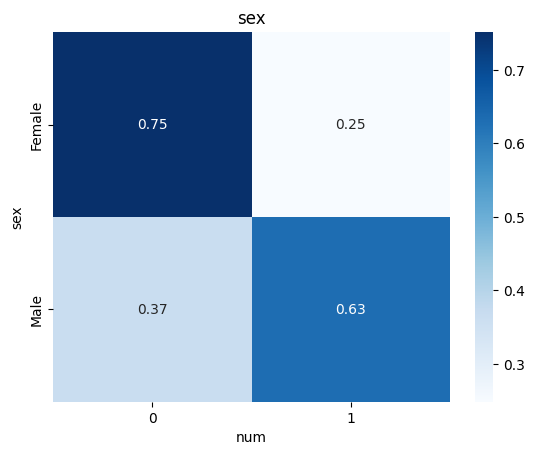

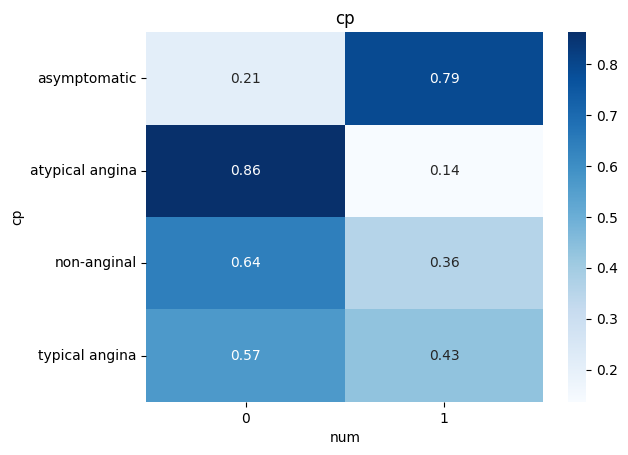

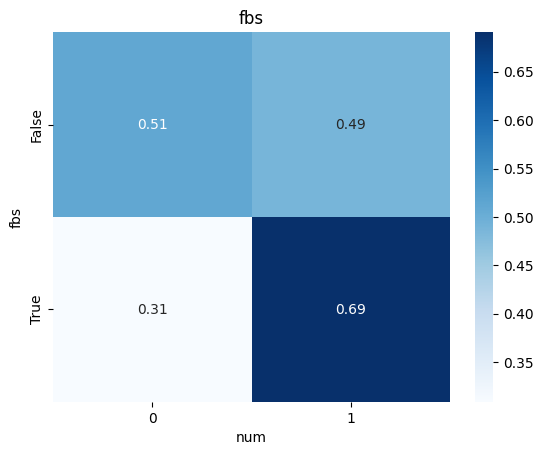

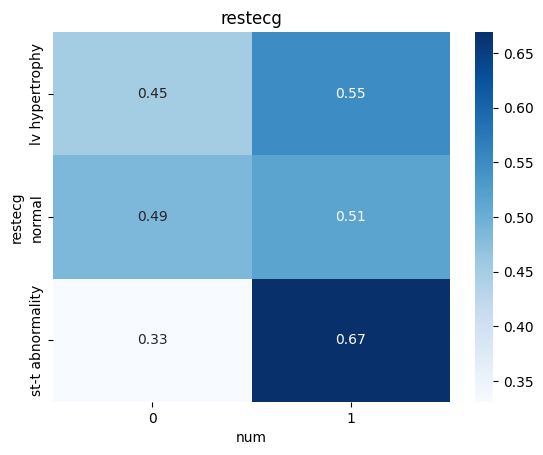

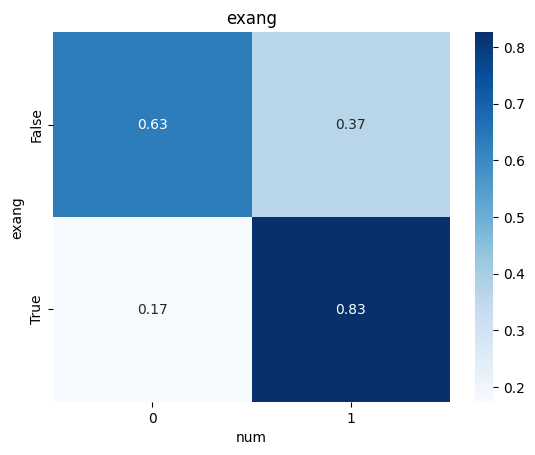

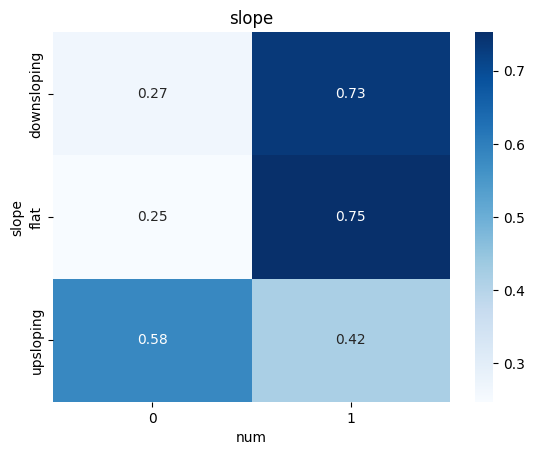

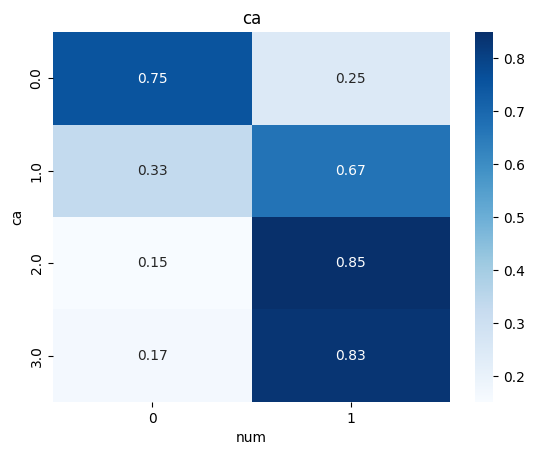

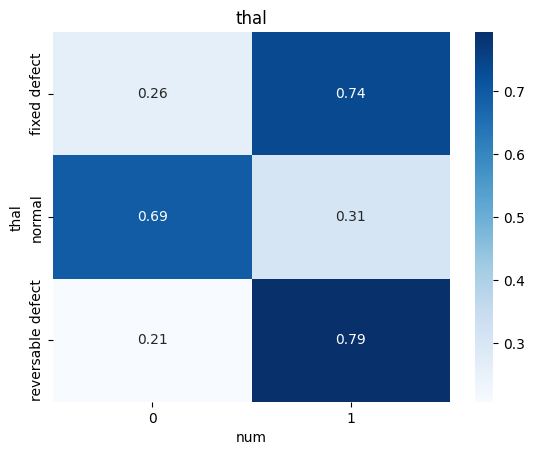

In [12]:
for col in TRAIN_CAT_COLS:
    ct = pd.crosstab(train_cat[col], train_cat[TARGET_COL], normalize="index")
    sns.heatmap(ct, annot=True, cmap="Blues")
    plt.title(col)
    plt.show()

array([[<Axes: xlabel='age', ylabel='age'>,
        <Axes: xlabel='trestbps', ylabel='age'>,
        <Axes: xlabel='chol', ylabel='age'>,
        <Axes: xlabel='thalch', ylabel='age'>,
        <Axes: xlabel='oldpeak', ylabel='age'>],
       [<Axes: xlabel='age', ylabel='trestbps'>,
        <Axes: xlabel='trestbps', ylabel='trestbps'>,
        <Axes: xlabel='chol', ylabel='trestbps'>,
        <Axes: xlabel='thalch', ylabel='trestbps'>,
        <Axes: xlabel='oldpeak', ylabel='trestbps'>],
       [<Axes: xlabel='age', ylabel='chol'>,
        <Axes: xlabel='trestbps', ylabel='chol'>,
        <Axes: xlabel='chol', ylabel='chol'>,
        <Axes: xlabel='thalch', ylabel='chol'>,
        <Axes: xlabel='oldpeak', ylabel='chol'>],
       [<Axes: xlabel='age', ylabel='thalch'>,
        <Axes: xlabel='trestbps', ylabel='thalch'>,
        <Axes: xlabel='chol', ylabel='thalch'>,
        <Axes: xlabel='thalch', ylabel='thalch'>,
        <Axes: xlabel='oldpeak', ylabel='thalch'>],
       [<Axes: xlab

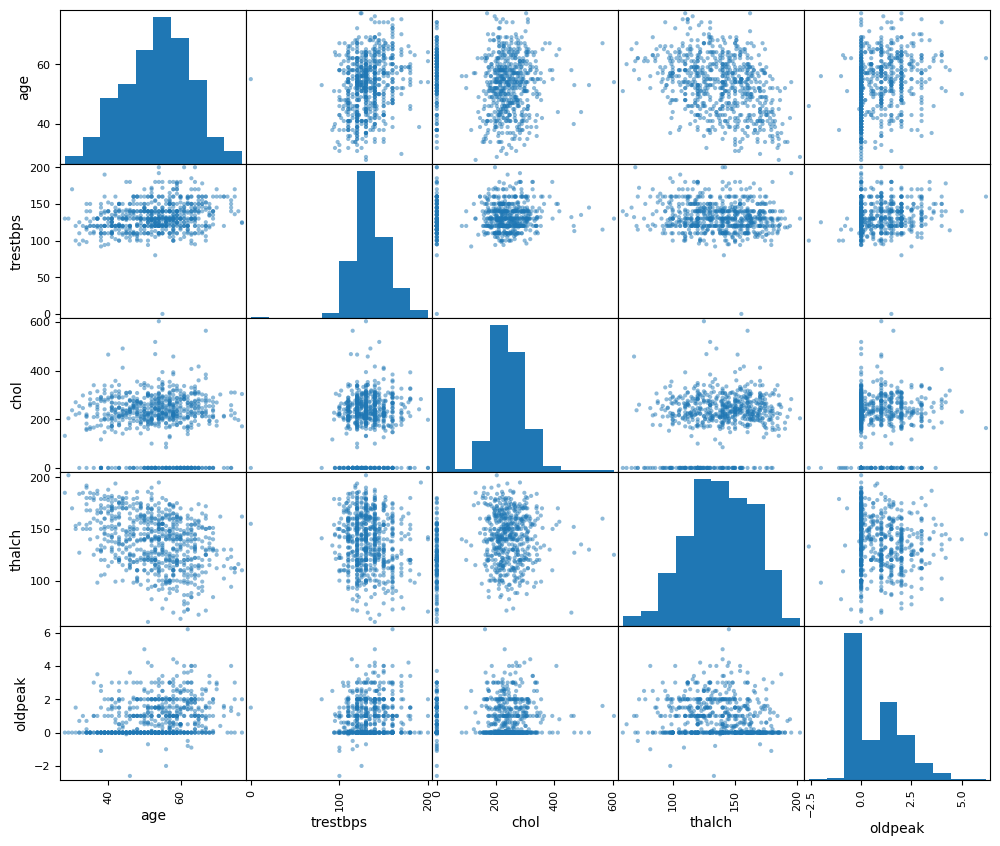

In [13]:
scatter_matrix(train_num, figsize=(12, 10))

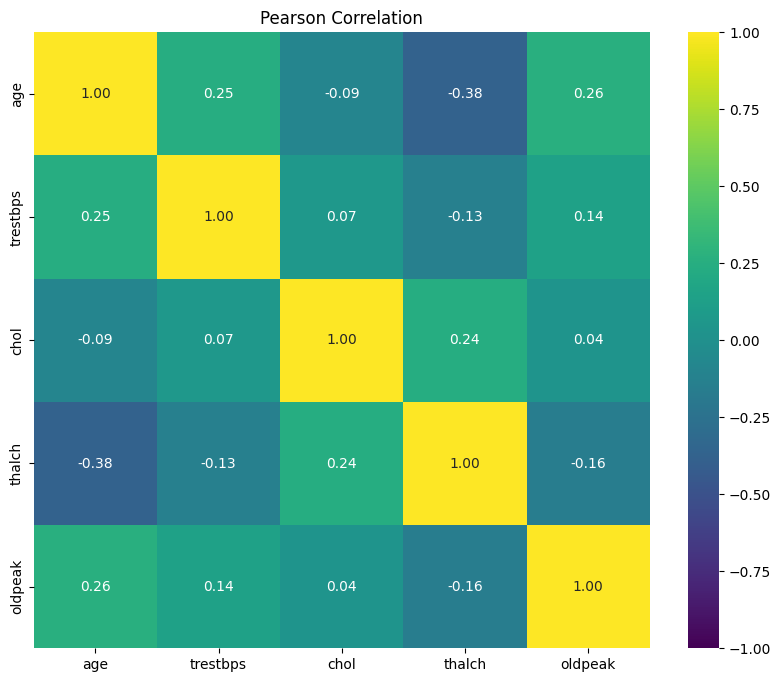

In [14]:
pearson_matrix = train_num.corr()
visualize_matrix(pearson_matrix, "Pearson Correlation")

interval columns not set, guessing: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num', 'metabolic_risk']


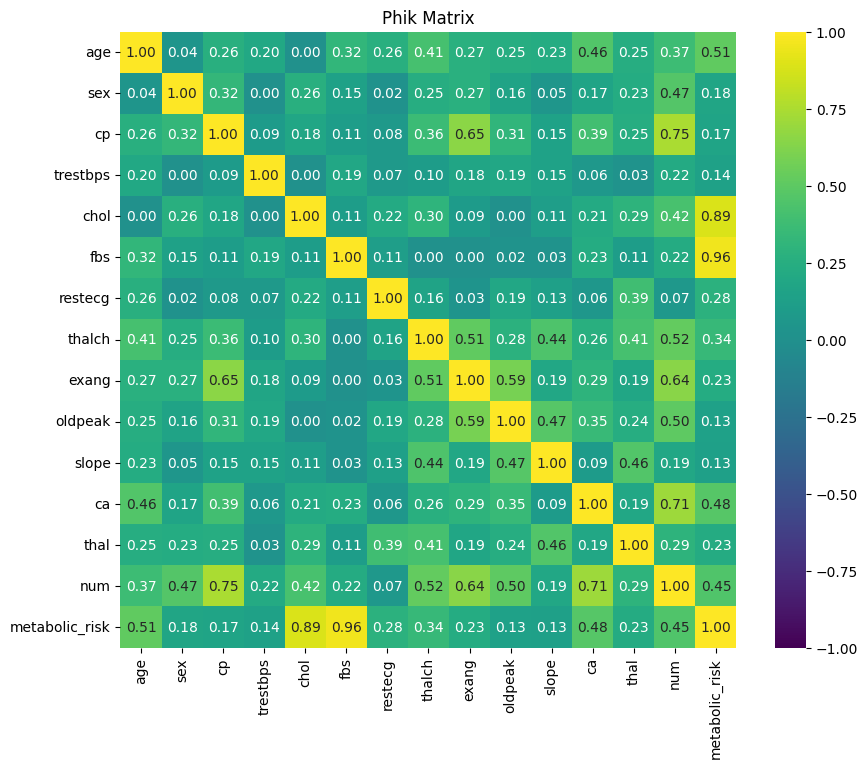

In [15]:
modified_train = train.copy()
modified_train['metabolic_risk'] = (
    (modified_train['chol']) *
    np.where(modified_train['fbs'] > 0, 2, 1) *
    (modified_train['age'])
)

phik_matrix = modified_train.phik_matrix()
visualize_matrix(phik_matrix, "Phik Matrix")

## Observations

- Dataset should be stratified by:
  -  num: ensures that the training data has the same proportions of the target value which avoid bia
  - cp: Strong predictor that needs to be represented accurately
- chol and oldpeak have a significant amount of values at 0, likely missing values.
- Irrelevant features:
  - id
  - sex
  - dataset
- Features with a large number of unknowns:
  - slope
  - ca
  - thal
- Right-skewed features
  - oldpeak
- Left-skewed features
  - chol
- Target classes are almost balanced, accuracy would be a suitable metric to evaluate models

# Preprocessing

In [16]:
preprocessor =build_preprocessing_pipeline()
preprocessor.fit(train_x)

Pipeline(steps=[('cleaning',
                 FunctionTransformer(feature_names_out='one-to-one',
                                     func=<function clean_data at 0x1345ba2a0>)),
                ('features',
                 FunctionTransformer(feature_names_out=<function get_updated_features at 0x1345bbce0>,
                                     func=<function feature_engineering at 0x1345ba340>)),
                ('column_tranformor',
                 ColumnTransformer(transformers=[('ordinal',
                                                  Pipeline(steps=[('impu...
                                                 ('normal_num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'thalch',
                                                   'age_thalch', 'bp_age',
                                                   'metabolic_risk']),
                                                 ('skewed_num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('power_transformer',
                                                                   PowerTransformer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['oldpeak', 'chol',
                                                   'stress_index',
                                                   'trestbps'])]))])

In [17]:
preprocessed_data = preprocessor.transform(train_x)
preprocessed_df = pd.DataFrame(
    preprocessed_data,
    columns=preprocessor.get_feature_names_out()
)
preprocessed_df.head()

,ordinal__cp,ordinal__slope,ordinal__thal,ordinal__ca,one_hot__restecg_normal,one_hot__restecg_st-t abnormality,one_hot__sex_Male,one_hot__fbs_True,one_hot__exang_True,normal_num__age,normal_num__thalch,normal_num__age_thalch,normal_num__bp_age,normal_num__metabolic_risk,skewed_num__oldpeak,skewed_num__chol,skewed_num__stress_index,skewed_num__trestbps
0,-1.505468,0.29508,-0.546212,-0.371496,0.0,1.0,1.0,0.0,0.0,0.150633,0.080245,-0.070806,-0.058988,-0.355902,0.035894,-0.273684,0.013689,-0.030545
1,0.862105,0.29508,3.011419,-0.371496,1.0,0.0,1.0,0.0,0.0,-1.341790,1.266196,-0.171877,-1.480894,-0.452059,0.035894,0.896778,0.013689,-1.337899
2,-1.505468,0.29508,1.232603,-0.371496,0.0,0.0,0.0,0.0,0.0,1.429853,0.870879,2.354891,0.367353,3.157524,0.188447,4.301768,-0.215203,-0.980398
3,-0.716277,0.29508,-0.546212,-0.371496,1.0,0.0,1.0,0.0,0.0,-1.128587,0.001182,-0.869939,-0.557638,-0.862292,0.035894,-0.745231,0.013689,0.621774
4,0.862105,0.29508,-0.546212,-0.371496,0.0,1.0,1.0,0.0,1.0,0.896844,0.001182,0.896778,1.576956,-0.634215,0.035894,-1.696382,0.013689,1.376679


# Model Training

## Random Forest Pipeline

In [18]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=SEED))
])

## Logistic Regression Pipeline

In [19]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state=SEED))
])

## XGBoost Pipeline

In [20]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(random_state=SEED))
])

## Results Without Fine-Tuning

In [21]:
cross_validate_model(rf_pipeline, train_x, train_y)

CV Mean Accuracy: 0.7880
CV Mean Precision: 0.7994
CV Mean Recall: 0.8253
CV Mean F1 Score: 0.8115


In [22]:
cross_validate_model(lr_pipeline, train_x, train_y)

CV Mean Accuracy: 0.7853
CV Mean Precision: 0.8009
CV Mean Recall: 0.8154
CV Mean F1 Score: 0.8072


In [23]:
cross_validate_model(xgb_pipeline, train_x, train_y)

CV Mean Accuracy: 0.7786
CV Mean Precision: 0.7906
CV Mean Recall: 0.8180
CV Mean F1 Score: 0.8033


# Fine Tuning

In [24]:
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

## Random Forest Fine-Tuning

In [25]:
param_dist_rf = {
    'model__n_estimators': [500],
    'model__max_features': ['sqrt'],
    'model__max_depth': [None, 5, 10, 15, 20, 25, 30],
    'model__min_samples_split': [2, 5, 10, 15, 20],
    'model__min_samples_leaf': [1, 2, 4, 8],
    'model__bootstrap': [True]
}

random_search_rf = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist_rf,
    n_iter=60,
    cv=10,
    scoring=scoring,
    refit='recall',
    random_state=SEED,
)

random_search_rf.fit(train_x, train_y)

RandomizedSearchCV(cv=10,
                   estimator=Pipeline(steps=[('preprocessor',
                                              Pipeline(steps=[('cleaning',
                                                               FunctionTransformer(feature_names_out='one-to-one',
                                                                                   func=<function clean_data at 0x1345ba2a0>)),
                                                              ('features',
                                                               FunctionTransformer(feature_names_out=<function get_updated_features at 0x1345bbce0>,
                                                                                   func=<function feature_engineering at 0x1345ba340>)),
                                                              ('column_tranformor...
                   n_iter=60,
                   param_distributions={'model__bootstrap': [True],
                                        'model__max_depth': [None, 5, 10, 15,
                                                             20, 25, 30],
                                        'model__max_features': ['sqrt'],
                                        'model__min_samples_leaf': [1, 2, 4, 8],
                                        'model__min_samples_split': [2, 5, 10,
                                                                     15, 20],
                                        'model__n_estimators': [500]},
                   random_state=42, refit='recall',
                   scoring={'accuracy': 'accuracy', 'f1': 'f1',
                            'precision': 'precision', 'recall': 'recall'})

In [ ]:
tuned_rf_model = random_search_rf.best_estimator_

best_params_rf = random_search_rf.best_params_
clean_rf_params = clean_params(best_params_rf)

print_search_cv_metrics(random_search_rf)


CV Mean Accuracy: 0.8057
CV Mean Precision: 0.8088
CV Mean Recall: 0.8524
CV Mean F1 Score: 0.8293

Best Parameters:
{'model__bootstrap': True,
 'model__max_depth': None,
 'model__max_features': 'sqrt',
 'model__min_samples_leaf': 4,
 'model__min_samples_split': 10,
 'model__n_estimators': 500}


## Logistic Regression Fine-Tuning

In [27]:
param_dist_lr = {
    'model__C': np.logspace(-3, 2, 20),   # 0.001 → 100
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs', 'liblinear'],
    'model__class_weight': [None, 'balanced']
}

random_search_lr = RandomizedSearchCV(
    lr_pipeline,
    param_distributions=param_dist_lr,
    n_iter=60,
    cv=10,
    scoring=scoring,
    refit='recall',
    random_state=SEED
)

random_search_lr.fit(train_x, train_y)

RandomizedSearchCV(cv=10,
                   estimator=Pipeline(steps=[('preprocessor',
                                              Pipeline(steps=[('cleaning',
                                                               FunctionTransformer(feature_names_out='one-to-one',
                                                                                   func=<function clean_data at 0x1345ba2a0>)),
                                                              ('features',
                                                               FunctionTransformer(feature_names_out=<function get_updated_features at 0x1345bbce0>,
                                                                                   func=<function feature_engineering at 0x1345ba340>)),
                                                              ('column_tranformor...
       1.27427499e-01, 2.33572147e-01, 4.28133240e-01, 7.84759970e-01,
       1.43844989e+00, 2.63665090e+00, 4.83293024e+00, 8.85866790e+00,
       1.62377674e+01, 2.97635144e+01, 5.45559478e+01, 1.00000000e+02]),
                                        'model__class_weight': [None,
                                                                'balanced'],
                                        'model__penalty': ['l2'],
                                        'model__solver': ['lbfgs',
                                                          'liblinear']},
                   random_state=42, refit='recall',
                   scoring={'accuracy': 'accuracy', 'f1': 'f1',
                            'precision': 'precision', 'recall': 'recall'})

In [28]:
tuned_lr_model = random_search_lr.best_estimator_

best_params_lr = random_search_lr.best_params_
clean_lr_params = clean_params(best_params_lr)

lr_search_metrics = print_search_cv_metrics(random_search_lr)

CV Mean Accuracy: 0.7378
CV Mean Precision: 0.7073
CV Mean Recall: 0.8990
CV Mean F1 Score: 0.7912

Best Parameters:
{'model__C': np.float64(0.001),
 'model__class_weight': None,
 'model__penalty': 'l2',
 'model__solver': 'lbfgs'}


## XGBoost Fine-Tuning

In [29]:
param_dist_xgb = {
    'model__n_estimators': [500],
    'model__max_depth': [3, 5, 7, 9],
    'model__learning_rate': [0.05],
    'model__gamma': [0, 0.1, 0.2, 0.3, 0.4],
    'model__subsample': [0.7, 0.8, 0.9],
    'model__colsample_bytree': [0.7, 0.8, 0.9],
    'model__min_child_weight': [1, 3, 5],
    'model__reg_lambda': [1, 1.5, 2, 5]
}

random_search_xgb = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=param_dist_xgb,
    n_iter=60,
    cv=10,
    scoring=scoring,
    refit='recall',
    random_state=SEED,
)

random_search_xgb.fit(train_x, train_y)

RandomizedSearchCV(cv=10,
                   estimator=Pipeline(steps=[('preprocessor',
                                              Pipeline(steps=[('cleaning',
                                                               FunctionTransformer(feature_names_out='one-to-one',
                                                                                   func=<function clean_data at 0x1345ba2a0>)),
                                                              ('features',
                                                               FunctionTransformer(feature_names_out=<function get_updated_features at 0x1345bbce0>,
                                                                                   func=<function feature_engineering at 0x1345ba340>)),
                                                              ('column_tranformor...
                   param_distributions={'model__colsample_bytree': [0.7, 0.8,
                                                                    0.9],
                                        'model__gamma': [0, 0.1, 0.2, 0.3, 0.4],
                                        'model__learning_rate': [0.05],
                                        'model__max_depth': [3, 5, 7, 9],
                                        'model__min_child_weight': [1, 3, 5],
                                        'model__n_estimators': [500],
                                        'model__reg_lambda': [1, 1.5, 2, 5],
                                        'model__subsample': [0.7, 0.8, 0.9]},
                   random_state=42, refit='recall',
                   scoring={'accuracy': 'accuracy', 'f1': 'f1',
                            'precision': 'precision', 'recall': 'recall'})

In [30]:
tuned_xgb_model = random_search_xgb.best_estimator_

best_params_xgb = random_search_xgb.best_params_
clean_xgb_params = clean_params(best_params_xgb)

print_search_cv_metrics(random_search_xgb)

CV Mean Accuracy: 0.8194
CV Mean Precision: 0.8274
CV Mean Recall: 0.8551
CV Mean F1 Score: 0.8400

Best Parameters:
{'model__colsample_bytree': 0.8,
 'model__gamma': 0.2,
 'model__learning_rate': 0.05,
 'model__max_depth': 7,
 'model__min_child_weight': 5,
 'model__n_estimators': 500,
 'model__reg_lambda': 5,
 'model__subsample': 0.7}


# Final Model Evaluation

Accuracy        : 0.8587
Precision       : 0.8519
Recall          : 0.9020
F1 Score        : 0.8762


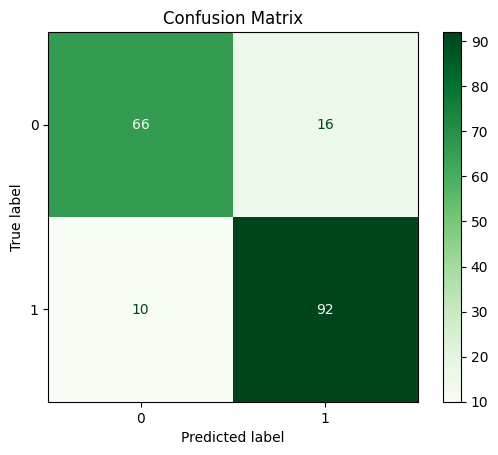

In [31]:
evaluate_model(tuned_rf_model, test_x, test_y)

Accuracy        : 0.7717
Precision       : 0.7273
Recall          : 0.9412
F1 Score        : 0.8205


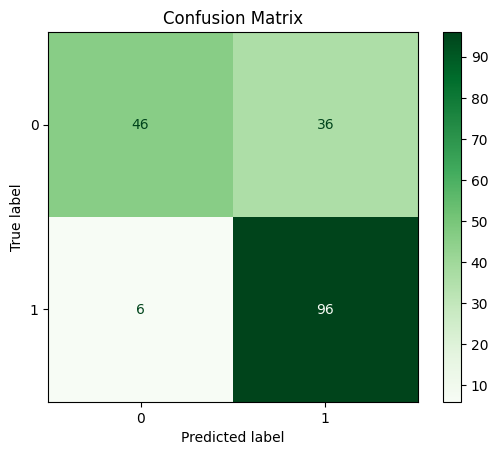

In [32]:
evaluate_model(tuned_lr_model, test_x, test_y)

Accuracy        : 0.8533
Precision       : 0.8713
Recall          : 0.8627
F1 Score        : 0.8670


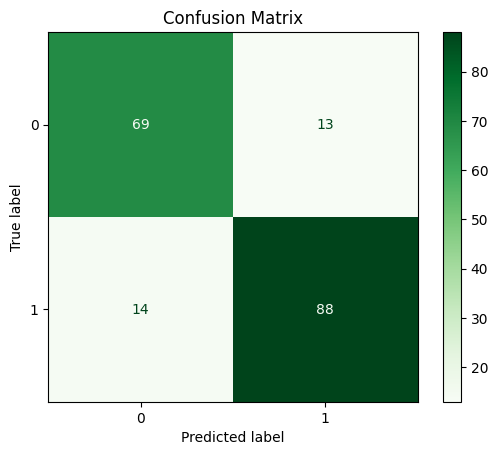

In [33]:
evaluate_model(tuned_xgb_model, test_x, test_y)

# Persisting Final Models

In [34]:
os.makedirs("models", exist_ok=True)

joblib.dump(tuned_rf_model, 'models/Random_Forest.pkl')
joblib.dump(tuned_lr_model, 'models/Logistic_Regression.pkl')
joblib.dump(tuned_xgb_model, 'models/XGBoost.pkl')

['models/XGBoost.pkl']